# 🚗 Vietnamese Vehicle Classification — InceptionV3

## Hệ thống Phân loại Phương tiện Giao thông Việt Nam

**Hướng dẫn sử dụng trên Kaggle:**
1. Tạo Notebook mới trên Kaggle
2. Bật GPU: **Settings → Accelerator → GPU T4 x2** hoặc **P100**
3. Upload `dataset.zip` lên Kaggle Datasets
4. Add dataset vào Notebook (nút **"+ Add Data"**)
5. ⚠️ **Sửa biến `DATASET_NAME` ở Cell 4** cho đúng tên dataset của bạn
6. Chạy tất cả cells

| Thông tin | Chi tiết |
|-----------|----------|
| Model | InceptionV3 (Transfer Learning) |
| Classes | bicycle, bus, car, motorcycle, truck |
| Input | 299 × 299 × 3 |
| Training | 2 stages (Freeze → Fine-tune) |
| GPU | Kaggle T4/P100 |

In [1]:
# =============================================================
# CELL 2: IMPORTS & KIỂM TRA GPU
# =============================================================

import os
import json
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger,
)
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

2026-03-14 09:24:17.555321: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773480257.788908      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773480257.850234      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773480258.329186      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773480258.329235      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773480258.329239      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## ⚙️ Cấu hình Constants

> ⚠️ **BẮT BUỘC**: Sửa biến `DATASET_NAME` bên dưới cho đúng tên dataset của bạn trên Kaggle!

In [24]:
# =============================================================
# CELL 4: CONSTANTS — KHÔNG SỬ DỤNG MAGIC NUMBERS
# =============================================================

# ⚠️ SỬA BIẾN NÀY CHO ĐÚNG TÊN DATASET CỦA BẠN TRÊN KAGGLE
DATASET_NAME = "vietnamese-vehicle-5-classes"

# Đường dẫn dữ liệu trên Kaggle
KAGGLE_INPUT = f"/kaggle/input/datasets/hieu411/{DATASET_NAME.split('/')[-1]}"
TRAIN_DIR = os.path.join(KAGGLE_INPUT, "train")
VAL_DIR = os.path.join(KAGGLE_INPUT, "val")
TEST_DIR = os.path.join(KAGGLE_INPUT, "test")

# Đường dẫn output trên Kaggle
OUTPUT_DIR = "/kaggle/working"

# Thông số mô hình
IMAGE_SIZE = (299, 299)           # Chuẩn InceptionV3
INPUT_SHAPE = (299, 299, 3)
NUM_CLASSES = 5
BATCH_SIZE = 32
RANDOM_SEED = 42

# Tên các class
# CLASS_NAMES = ["bus", "truck", "car", "motorcycle", "bicycle"]
# CLASS_NAMES_VI = {
#     "bus": "Xe buýt",
#     "truck": "Xe tải",
#     "car": "Xe ô tô con",
#     "motorcycle": "Xe máy",
#     "bicycle": "Xe đạp",
# }

CLASS_NAMES = ["bicycle", "bus", "car", "motorcycle", "truck"]
CLASS_NAMES_VI = {
    "bicycle": "Xe đạp",
    "bus": "Xe buýt",
    "car": "Xe ô tô con",
    "motorcycle": "Xe máy",
    "truck": "Xe tải",
}

# Hyperparameters — Stage 1 (Freeze base, train head)
STAGE1_EPOCHS = 10
STAGE1_LR = 1e-3

# Hyperparameters — Stage 2 (Fine-tune top layers)
STAGE2_EPOCHS = 40
STAGE2_LR = 1e-5
STAGE2_UNFREEZE_LAYERS = 50

# Callbacks
EARLY_STOPPING_PATIENCE = 10
REDUCE_LR_PATIENCE = 5
REDUCE_LR_FACTOR = 0.5
REDUCE_LR_MIN = 1e-7

# Tên file output
BEST_MODEL_FILE = os.path.join(OUTPUT_DIR, "inception_v3_best.h5")
FINAL_MODEL_FILE = os.path.join(OUTPUT_DIR, "inception_v3_final.h5")
HISTORY_FILE = os.path.join(OUTPUT_DIR, "training_history.json")
CSV_LOG_FILE = os.path.join(OUTPUT_DIR, "training_log.csv")

print("✅ Đã cấu hình tất cả constants")
print(f"   Dataset path: {KAGGLE_INPUT}")
print(f"   Image size: {IMAGE_SIZE}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Num classes: {NUM_CLASSES}")

✅ Đã cấu hình tất cả constants
   Dataset path: /kaggle/input/datasets/hieu411/vietnamese-vehicle-5-classes
   Image size: (299, 299)
   Batch size: 32
   Num classes: 5


## 🎲 Random Seed (Reproducibility)

In [3]:
# =============================================================
# CELL 6: SET RANDOM SEED (KT-004)
# =============================================================

def dat_random_seed(seed: int = RANDOM_SEED) -> None:
    """Đặt random seed cho tất cả thư viện để đảm bảo reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"✅ Random seed đã được đặt: {seed}")

dat_random_seed()

✅ Random seed đã được đặt: 42


## 📂 Kiểm tra Dữ liệu trên Kaggle

In [4]:
# =============================================================
# CELL 8: KIỂM TRA DỮ LIỆU (KT-002, KT-003)
# =============================================================

def kiem_tra_du_lieu() -> None:
    """Kiểm tra cấu trúc thư mục và đếm ảnh trong mỗi split/class."""
    print("📂 Kiểm tra dữ liệu trên Kaggle...")
    print(f"   Input path: {KAGGLE_INPUT}")
    print()

    tong_anh = 0

    for split_name, split_dir in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test", TEST_DIR)]:
        if not os.path.exists(split_dir):
            print(f"❌ KHÔNG TÌM THẤY: {split_dir}")
            print(f"   → Hãy kiểm tra lại tên dataset và cấu trúc zip!")
            return

        split_total = 0
        print(f"📁 {split_name}/")
        for class_name in sorted(os.listdir(split_dir)):
            class_dir = os.path.join(split_dir, class_name)
            if os.path.isdir(class_dir):
                so_anh = len([
                    f for f in os.listdir(class_dir)
                    if f.lower().endswith((".jpg", ".jpeg", ".png"))
                ])
                ten_vn = CLASS_NAMES_VI.get(class_name, class_name)
                print(f"   ├── {class_name}/ ({ten_vn}): {so_anh} ảnh")
                split_total += so_anh
        print(f"   └── Tổng: {split_total} ảnh")
        tong_anh += split_total
        print()

    print(f"📊 Tổng toàn bộ: {tong_anh} ảnh")
    print("✅ Kiểm tra dữ liệu hoàn tất!")

kiem_tra_du_lieu()

📂 Kiểm tra dữ liệu trên Kaggle...
   Input path: /kaggle/input/datasets/hieu411/vietnamese-vehicle-5-classes

📁 train/
   ├── bicycle/ (Xe đạp): 3200 ảnh
   ├── bus/ (Xe buýt): 3200 ảnh
   ├── car/ (Xe ô tô con): 3200 ảnh
   ├── motorcycle/ (Xe máy): 2971 ảnh
   ├── truck/ (Xe tải): 3200 ảnh
   └── Tổng: 15771 ảnh

📁 val/
   ├── bicycle/ (Xe đạp): 400 ảnh
   ├── bus/ (Xe buýt): 400 ảnh
   ├── car/ (Xe ô tô con): 400 ảnh
   ├── motorcycle/ (Xe máy): 371 ảnh
   ├── truck/ (Xe tải): 400 ảnh
   └── Tổng: 1971 ảnh

📁 test/
   ├── bicycle/ (Xe đạp): 400 ảnh
   ├── bus/ (Xe buýt): 400 ảnh
   ├── car/ (Xe ô tô con): 400 ảnh
   ├── motorcycle/ (Xe máy): 372 ảnh
   ├── truck/ (Xe tải): 400 ảnh
   └── Tổng: 1972 ảnh

📊 Tổng toàn bộ: 19714 ảnh
✅ Kiểm tra dữ liệu hoàn tất!


## 📊 Data Pipeline (ImageDataGenerator + Augmentation)

In [5]:
# =============================================================
# CELL 10: DATA PIPELINE (KT-005, KT-006, KT-007, KT-008)
# =============================================================

def tao_data_generators() -> tuple:
    """
    Tạo ImageDataGenerator cho train (có augmentation) và val/test (chỉ rescale).

    Trả về:
        Tuple (train_gen, val_gen, test_gen) — 3 data generators
    """
    # Generator cho TRAINING — có data augmentation
    train_datagen = ImageDataGenerator(
        rescale=1.0 / 255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        zoom_range=0.2,
        shear_range=0.1,
        fill_mode="nearest",
    )

    # Generator cho VALIDATION/TEST — chỉ rescale, KHÔNG augmentation
    val_test_datagen = ImageDataGenerator(
        rescale=1.0 / 255,
    )

    # Tạo flow_from_directory
    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=True,
        seed=RANDOM_SEED,
    )

    val_gen = val_test_datagen.flow_from_directory(
        VAL_DIR,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False,
    )

    test_gen = val_test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False,
    )

    # In thông tin
    print(f"\n📊 Train:      {train_gen.samples} ảnh, {train_gen.num_classes} classes")
    print(f"📊 Validation: {val_gen.samples} ảnh, {val_gen.num_classes} classes")
    print(f"📊 Test:       {test_gen.samples} ảnh, {test_gen.num_classes} classes")
    print(f"📊 Class indices: {train_gen.class_indices}")

    # Verify batch shape
    batch_x, batch_y = next(train_gen)
    print(f"\n✅ Batch shape: X={batch_x.shape}, Y={batch_y.shape}")
    assert batch_x.shape[1:] == INPUT_SHAPE, f"Sai input shape! Expected {INPUT_SHAPE}"

    return train_gen, val_gen, test_gen

train_gen, val_gen, test_gen = tao_data_generators()

Found 15771 images belonging to 5 classes.
Found 1971 images belonging to 5 classes.
Found 1972 images belonging to 5 classes.

📊 Train:      15771 ảnh, 5 classes
📊 Validation: 1971 ảnh, 5 classes
📊 Test:       1972 ảnh, 5 classes
📊 Class indices: {'bicycle': 0, 'bus': 1, 'car': 2, 'motorcycle': 3, 'truck': 4}

✅ Batch shape: X=(32, 299, 299, 3), Y=(32, 5)


## 🔍 Xem mẫu ảnh sau Augmentation

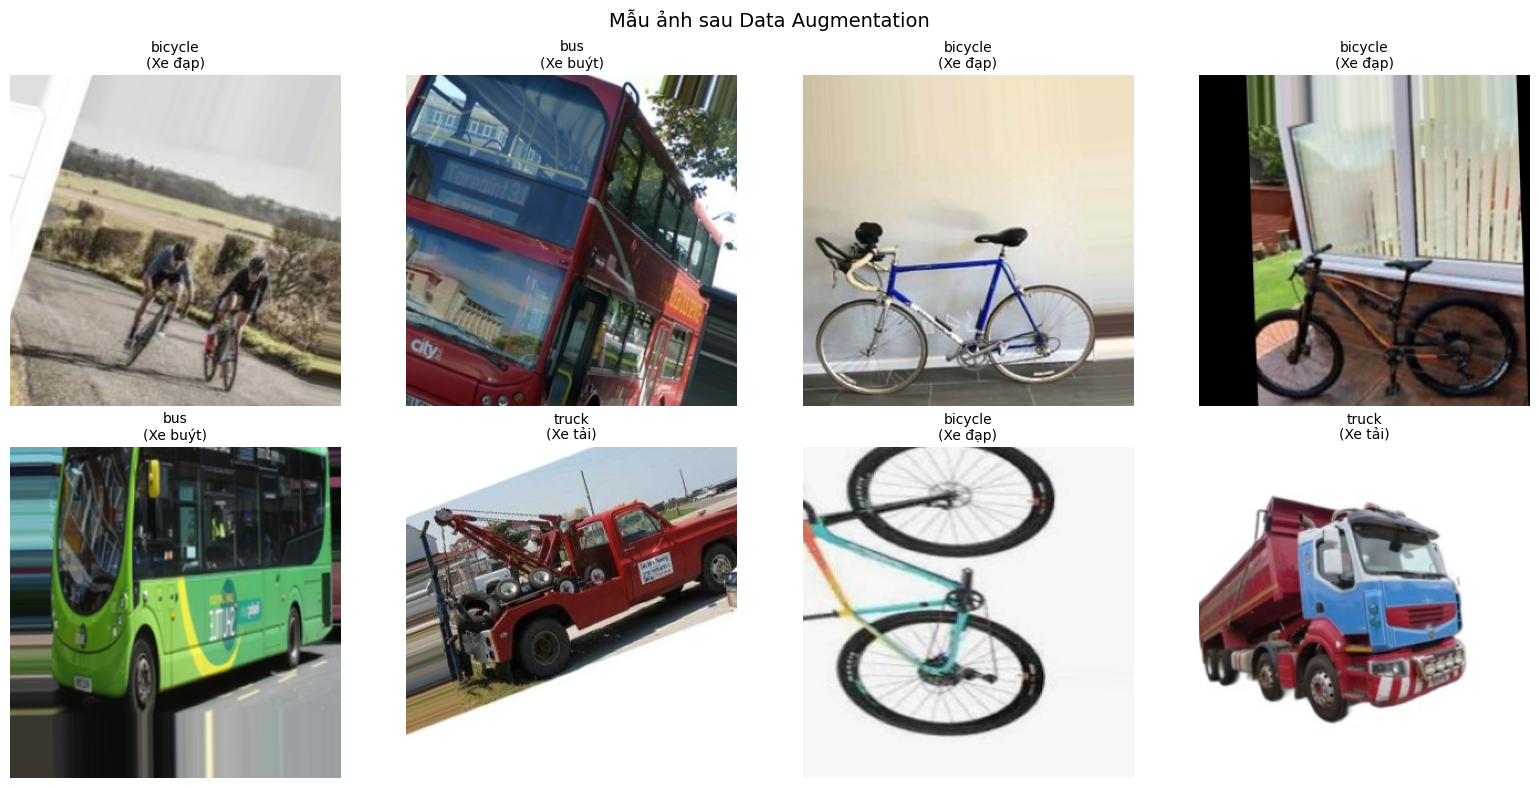

In [6]:
# =============================================================
# CELL 12: VISUALIZE AUGMENTED SAMPLES
# =============================================================

def hien_thi_mau_augmented(train_gen, so_anh: int = 8) -> None:
    """Hiển thị một số ảnh mẫu sau augmentation để kiểm tra."""
    batch_x, batch_y = next(train_gen)
    class_labels = list(train_gen.class_indices.keys())

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i, ax in enumerate(axes.flat):
        if i < so_anh and i < len(batch_x):
            ax.imshow(batch_x[i])
            class_idx = np.argmax(batch_y[i])
            ten_class = class_labels[class_idx]
            ten_vn = CLASS_NAMES_VI.get(ten_class, ten_class)
            ax.set_title(f"{ten_class}\n({ten_vn})", fontsize=10)
            ax.axis("off")

    plt.suptitle("Mẫu ảnh sau Data Augmentation", fontsize=14)
    plt.tight_layout()
    plt.show()

hien_thi_mau_augmented(train_gen)

## 🧠 Model Architecture (InceptionV3 + Custom Head)

In [7]:
# =============================================================
# CELL 14: MODEL ARCHITECTURE (KT-009, KT-010, KT-011, KT-012)
# =============================================================

def tao_model() -> Model:
    """
    Tạo mô hình InceptionV3 với transfer learning.

    Kiến trúc:
        InceptionV3 (ImageNet, freeze) → GlobalAvgPool → Dense(256) → Dropout(0.5) → Dense(4, softmax)

    Trả về:
        Model Keras đã compile
    """
    # Load InceptionV3 pre-trained trên ImageNet, bỏ phần head gốc
    base_model = InceptionV3(
        weights="imagenet",
        include_top=False,
        input_shape=INPUT_SHAPE,
    )

    # Đóng băng toàn bộ base model (Stage 1)
    base_model.trainable = False

    # Thêm custom classification head
    x = base_model.output
    x = GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = Dense(256, activation="relu", name="dense_256")(x)
    x = Dropout(0.5, name="dropout_05")(x)
    predictions = Dense(NUM_CLASSES, activation="softmax", name="output")(x)

    # Tạo model hoàn chỉnh
    model = Model(
        inputs=base_model.input,
        outputs=predictions,
        name="VehicleClassifier_InceptionV3",
    )

    # Compile với Adam optimizer
    model.compile(
        optimizer=Adam(learning_rate=STAGE1_LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    # In thông tin model
    tong_params = model.count_params()
    trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
    non_trainable = tong_params - trainable

    print(f"📐 Model: {model.name}")
    print(f"   Tổng parameters:     {tong_params:,}")
    print(f"   Trainable params:    {trainable:,}")
    print(f"   Non-trainable params: {non_trainable:,}")
    print(f"   Output shape:        {model.output_shape}")

    return model

model = tao_model()

I0000 00:00:1773480295.441827      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773480295.447832      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
📐 Model: VehicleClassifier_InceptionV3
   Tổng parameters:     22,328,613
   Trainable params:    525,829
   Non-trainable params: 21,802,784
   Output shape:        (None, 5)


In [8]:
# =============================================================
# CELL 15: MODEL SUMMARY
# =============================================================

model.summary()

Model: "VehicleClassifier_InceptionV3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 22,328,613 (85.18 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

## 📞 Callbacks Configuration

In [9]:
# =============================================================
# CELL 17: CALLBACKS (KT-013, KT-014, KT-015, KT-016)
# =============================================================

def tao_callbacks() -> list:
    """
    Tạo danh sách callbacks cho training.

    Trả về:
        List các callback objects
    """
    callbacks = [
        # Lưu model tốt nhất theo val_accuracy
        ModelCheckpoint(
            filepath=BEST_MODEL_FILE,
            monitor="val_accuracy",
            save_best_only=True,
            mode="max",
            verbose=1,
        ),
        # Dừng sớm nếu val_accuracy không cải thiện
        EarlyStopping(
            monitor="val_accuracy",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),
        # Giảm learning rate khi val_loss không giảm
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=REDUCE_LR_FACTOR,
            patience=REDUCE_LR_PATIENCE,
            min_lr=REDUCE_LR_MIN,
            verbose=1,
        ),
        # Lưu log training ra CSV
        CSVLogger(
            CSV_LOG_FILE,
            append=True,
        ),
    ]

    print(f"✅ Đã tạo {len(callbacks)} callbacks:")
    print(f"   • ModelCheckpoint → {BEST_MODEL_FILE}")
    print(f"   • EarlyStopping (patience={EARLY_STOPPING_PATIENCE})")
    print(f"   • ReduceLROnPlateau (factor={REDUCE_LR_FACTOR}, patience={REDUCE_LR_PATIENCE})")
    print(f"   • CSVLogger → {CSV_LOG_FILE}")

    return callbacks

callbacks = tao_callbacks()

✅ Đã tạo 4 callbacks:
   • ModelCheckpoint → /kaggle/working/inception_v3_best.h5
   • EarlyStopping (patience=10)
   • ReduceLROnPlateau (factor=0.5, patience=5)
   • CSVLogger → /kaggle/working/training_log.csv


## 🚀 Stage 1: Freeze Base — Train Head Only

> Đóng băng toàn bộ InceptionV3, chỉ train custom head (GlobalAvgPool → Dense → Dropout → Output).
> - Epochs: **10**
> - Learning rate: **1e-3**

In [10]:
# =============================================================
# CELL 19: STAGE 1 — FREEZE BASE, TRAIN HEAD (KT-018)
# =============================================================

print("=" * 60)
print("🚀 STAGE 1: FREEZE BASE — TRAIN HEAD ONLY")
print(f"   Epochs: {STAGE1_EPOCHS} | LR: {STAGE1_LR}")
print("=" * 60)

history_stage1 = model.fit(
    train_gen,
    epochs=STAGE1_EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1,
)

print(f"\n✅ Stage 1 hoàn thành!")
print(f"   Train accuracy: {history_stage1.history['accuracy'][-1]:.4f}")
print(f"   Val accuracy:   {history_stage1.history['val_accuracy'][-1]:.4f}")

🚀 STAGE 1: FREEZE BASE — TRAIN HEAD ONLY
   Epochs: 10 | LR: 0.001


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1773480308.123047     147 service.cc:152] XLA service 0x785dec006120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773480308.123083     147 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773480308.123090     147 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773480310.454873     147 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/493 ━━━━━━━━━━━━━━━━━━━━ 2:43:44 20s/step - accuracy: 0.2812 - loss: 1.7379

I0000 00:00:1773480320.536334     147 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 746ms/step - accuracy: 0.9275 - loss: 0.2091
Epoch 1: val_accuracy improved from -inf to 0.99493, saving model to /kaggle/working/inception_v3_best.h5


493/493 ━━━━━━━━━━━━━━━━━━━━ 416s 805ms/step - accuracy: 0.9275 - loss: 0.2090 - val_accuracy: 0.9949 - val_loss: 0.0153 - learning_rate: 0.0010
Epoch 2/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.9690 - loss: 0.0886
Epoch 2: val_accuracy did not improve from 0.99493
493/493 ━━━━━━━━━━━━━━━━━━━━ 330s 670ms/step - accuracy: 0.9690 - loss: 0.0886 - val_accuracy: 0.9934 - val_loss: 0.0192 - learning_rate: 0.0010
Epoch 3/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.9743 - loss: 0.0753
Epoch 3: val_accuracy improved from 0.99493 to 0.99594, saving model to /kaggle/working/inception_v3_best.h5


493/493 ━━━━━━━━━━━━━━━━━━━━ 325s 660ms/step - accuracy: 0.9743 - loss: 0.0753 - val_accuracy: 0.9959 - val_loss: 0.0146 - learning_rate: 0.0010
Epoch 4/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.9807 - loss: 0.0637
Epoch 4: val_accuracy did not improve from 0.99594
493/493 ━━━━━━━━━━━━━━━━━━━━ 331s 670ms/step - accuracy: 0.9807 - loss: 0.0637 - val_accuracy: 0.9939 - val_loss: 0.0165 - learning_rate: 0.0010
Epoch 5/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - accuracy: 0.9749 - loss: 0.0706
Epoch 5: val_accuracy did not improve from 0.99594
493/493 ━━━━━━━━━━━━━━━━━━━━ 328s 664ms/step - accuracy: 0.9749 - loss: 0.0706 - val_accuracy: 0.9904 - val_loss: 0.0279 - learning_rate: 0.0010
Epoch 6/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - accuracy: 0.9800 - loss: 0.0658
Epoch 6: val_accuracy did not improve from 0.99594
493/493 ━━━━━━━━━━━━━━━━━━━━ 330s 670ms/step - accuracy: 0.9800 - loss: 0.0658 - val_accuracy: 0.9954 - val_loss: 0.0193 - learning_rate: 0.0010
Epo

493/493 ━━━━━━━━━━━━━━━━━━━━ 331s 671ms/step - accuracy: 0.9847 - loss: 0.0474 - val_accuracy: 0.9985 - val_loss: 0.0090 - learning_rate: 5.0000e-04
Epoch 10/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.9855 - loss: 0.0452
Epoch 10: val_accuracy did not improve from 0.99848
493/493 ━━━━━━━━━━━━━━━━━━━━ 338s 686ms/step - accuracy: 0.9855 - loss: 0.0452 - val_accuracy: 0.9975 - val_loss: 0.0097 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 9.

✅ Stage 1 hoàn thành!
   Train accuracy: 0.9860
   Val accuracy:   0.9975


## 🚀 Stage 2: Fine-tune Top Layers

> Mở khóa **50 layers cuối** của InceptionV3 và train tiếp với learning rate nhỏ.
> - Epochs: **40**
> - Learning rate: **1e-5**
> - Unfreeze: **50 layers**

In [11]:
# =============================================================
# CELL 21: CẤU HÌNH STAGE 2 — UNFREEZE TOP LAYERS (KT-019)
# =============================================================

print("=" * 60)
print("🚀 STAGE 2: FINE-TUNE TOP LAYERS")
print(f"   Unfreeze: {STAGE2_UNFREEZE_LAYERS} layers | Epochs: {STAGE2_EPOCHS} | LR: {STAGE2_LR}")
print("=" * 60)

# Tìm base model (InceptionV3) trong model
base_model = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        base_model = layer
        break

if base_model is not None:
    # Mở khóa base model
    base_model.trainable = True
    # Đóng băng lại tất cả layer trừ top N
    for layer in base_model.layers[:-STAGE2_UNFREEZE_LAYERS]:
        layer.trainable = False
    print(f"   Base model: {base_model.name}")
    print(f"   Tổng layers: {len(base_model.layers)}")
    print(f"   Đã unfreeze: {STAGE2_UNFREEZE_LAYERS} layers cuối")
else:
    # Fallback: unfreeze trực tiếp top layers của model
    for layer in model.layers[-(STAGE2_UNFREEZE_LAYERS + 3):]:
        layer.trainable = True
    print("   ⚠️ Không tìm thấy sub-model, unfreeze trực tiếp top layers")

# Compile lại với learning rate nhỏ hơn
model.compile(
    optimizer=Adam(learning_rate=STAGE2_LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# Đếm trainable params sau unfreeze
trainable_s2 = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"   Trainable params (Stage 2): {trainable_s2:,}")

🚀 STAGE 2: FINE-TUNE TOP LAYERS
   Unfreeze: 50 layers | Epochs: 40 | LR: 1e-05
   ⚠️ Không tìm thấy sub-model, unfreeze trực tiếp top layers
   Trainable params (Stage 2): 7,256,773


In [12]:
# =============================================================
# CELL 22: CHẠY TRAINING STAGE 2
# =============================================================

history_stage2 = model.fit(
    train_gen,
    epochs=STAGE2_EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1,
)

print(f"\n✅ Stage 2 hoàn thành!")
print(f"   Train accuracy: {history_stage2.history['accuracy'][-1]:.4f}")
print(f"   Val accuracy:   {history_stage2.history['val_accuracy'][-1]:.4f}")

Epoch 1/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.9706 - loss: 0.0880
Epoch 1: val_accuracy did not improve from 0.99848
493/493 ━━━━━━━━━━━━━━━━━━━━ 375s 718ms/step - accuracy: 0.9706 - loss: 0.0880 - val_accuracy: 0.9970 - val_loss: 0.0113 - learning_rate: 1.0000e-05
Epoch 2/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.9823 - loss: 0.0546
Epoch 2: val_accuracy did not improve from 0.99848
493/493 ━━━━━━━━━━━━━━━━━━━━ 338s 686ms/step - accuracy: 0.9823 - loss: 0.0546 - val_accuracy: 0.9985 - val_loss: 0.0075 - learning_rate: 1.0000e-05
Epoch 3/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.9853 - loss: 0.0497
Epoch 3: val_accuracy did not improve from 0.99848
493/493 ━━━━━━━━━━━━━━━━━━━━ 338s 685ms/step - accuracy: 0.9853 - loss: 0.0496 - val_accuracy: 0.9980 - val_loss: 0.0065 - learning_rate: 1.0000e-05
Epoch 4/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.9851 - loss: 0.0456
Epoch 4: val_accuracy did not improve from 0.998

493/493 ━━━━━━━━━━━━━━━━━━━━ 344s 697ms/step - accuracy: 0.9881 - loss: 0.0363 - val_accuracy: 0.9990 - val_loss: 0.0052 - learning_rate: 1.0000e-05
Epoch 6/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.9907 - loss: 0.0299
Epoch 6: val_accuracy did not improve from 0.99899
493/493 ━━━━━━━━━━━━━━━━━━━━ 345s 700ms/step - accuracy: 0.9907 - loss: 0.0299 - val_accuracy: 0.9980 - val_loss: 0.0069 - learning_rate: 1.0000e-05
Epoch 7/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.9914 - loss: 0.0256
Epoch 7: val_accuracy did not improve from 0.99899
493/493 ━━━━━━━━━━━━━━━━━━━━ 342s 694ms/step - accuracy: 0.9914 - loss: 0.0256 - val_accuracy: 0.9980 - val_loss: 0.0046 - learning_rate: 1.0000e-05
Epoch 8/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 671ms/step - accuracy: 0.9922 - loss: 0.0238
Epoch 8: val_accuracy did not improve from 0.99899
493/493 ━━━━━━━━━━━━━━━━━━━━ 342s 694ms/step - accuracy: 0.9922 - loss: 0.0238 - val_accuracy: 0.9980 - val_loss: 0.0048 - learning_rate

## 💾 Lưu Model & Training History

In [13]:
# =============================================================
# CELL 24: LƯU MODEL & HISTORY (KT-022, KT-024)
# =============================================================

# Lưu model cuối cùng
model.save(FINAL_MODEL_FILE)
print(f"💾 Đã lưu model cuối cùng: {FINAL_MODEL_FILE}")

# Gộp history từ 2 stages
full_history = {}
for key in history_stage1.history:
    full_history[key] = history_stage1.history[key] + history_stage2.history[key]

# Lưu training history sang JSON
with open(HISTORY_FILE, "w") as f:
    serializable = {k: [float(v) for v in vals] for k, vals in full_history.items()}
    json.dump(serializable, f, indent=2)
print(f"📊 Đã lưu training history: {HISTORY_FILE}")

# In kích thước file model
model_size_mb = os.path.getsize(FINAL_MODEL_FILE) / (1024 * 1024)
best_size_mb = os.path.getsize(BEST_MODEL_FILE) / (1024 * 1024)
print(f"\n📦 Kích thước model:")
print(f"   Final: {model_size_mb:.1f} MB")
print(f"   Best:  {best_size_mb:.1f} MB")

💾 Đã lưu model cuối cùng: /kaggle/working/inception_v3_final.h5
📊 Đã lưu training history: /kaggle/working/training_history.json

📦 Kích thước model:
   Final: 141.5 MB
   Best:  141.5 MB


## 📈 Training Curves (Accuracy & Loss)

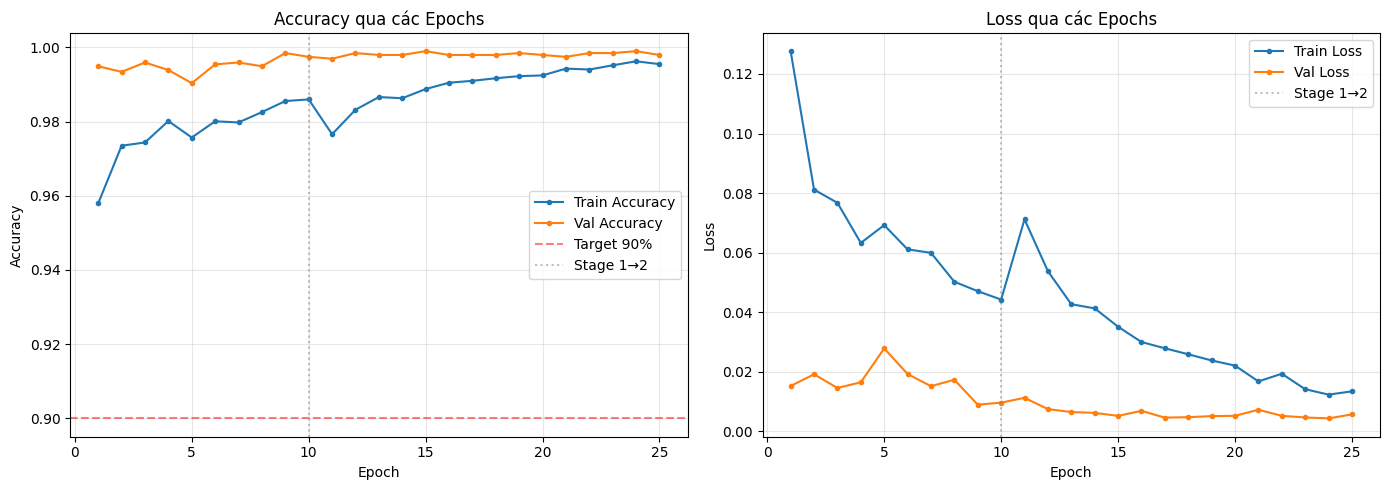

📈 Đã lưu training_curves.png


In [14]:
# =============================================================
# CELL 26: VẼ TRAINING CURVES (KT-020)
# =============================================================

def ve_training_curves(history: dict) -> None:
    """Vẽ biểu đồ Accuracy và Loss qua các epochs."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs_range = range(1, len(history["accuracy"]) + 1)

    # --- Accuracy ---
    axes[0].plot(epochs_range, history["accuracy"], label="Train Accuracy", marker=".")
    axes[0].plot(epochs_range, history["val_accuracy"], label="Val Accuracy", marker=".")
    axes[0].axhline(y=0.9, color="red", linestyle="--", alpha=0.5, label="Target 90%")
    axes[0].axvline(x=STAGE1_EPOCHS, color="gray", linestyle=":", alpha=0.5, label="Stage 1→2")
    axes[0].set_title("Accuracy qua các Epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # --- Loss ---
    axes[1].plot(epochs_range, history["loss"], label="Train Loss", marker=".")
    axes[1].plot(epochs_range, history["val_loss"], label="Val Loss", marker=".")
    axes[1].axvline(x=STAGE1_EPOCHS, color="gray", linestyle=":", alpha=0.5, label="Stage 1→2")
    axes[1].set_title("Loss qua các Epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
    plt.show()
    print("📈 Đã lưu training_curves.png")

ve_training_curves(full_history)

## 📊 Đánh giá Model trên Test Set

In [15]:
# =============================================================
# CELL 28: EVALUATE TRÊN TEST SET (KT-021)
# =============================================================

def danh_gia_model(model: Model, test_gen) -> dict:
    """
    Đánh giá model trên test set.

    Tham số:
        model: Model đã train
        test_gen: Test data generator

    Trả về:
        Dict chứa kết quả evaluation
    """
    print("=" * 60)
    print("📊 KẾT QUẢ ĐÁNH GIÁ TRÊN TEST SET")
    print("=" * 60)

    # Evaluate tổng thể
    test_loss, test_acc = model.evaluate(test_gen, verbose=0)
    print(f"\n🎯 Test Loss:     {test_loss:.4f}")
    print(f"🎯 Test Accuracy: {test_acc:.4f} ({test_acc * 100:.1f}%)")

    if test_acc >= 0.9:
        print("✅ ĐẠT MỤC TIÊU > 90%!")
    else:
        print(f"⚠️  Chưa đạt mục tiêu 90% (thiếu {(0.9 - test_acc) * 100:.1f}%)")

    # Predictions
    test_gen.reset()
    y_pred_probs = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_gen.classes
    class_labels = list(test_gen.class_indices.keys())

    # Classification Report
    print("\n📋 Classification Report:")
    print("-" * 60)
    print(classification_report(y_true, y_pred, target_names=class_labels))

    return {
        "test_loss": float(test_loss),
        "test_accuracy": float(test_acc),
        "y_true": y_true,
        "y_pred": y_pred,
        "class_labels": class_labels,
    }

eval_results = danh_gia_model(model, test_gen)

📊 KẾT QUẢ ĐÁNH GIÁ TRÊN TEST SET

🎯 Test Loss:     0.0083
🎯 Test Accuracy: 0.9975 (99.7%)
✅ ĐẠT MỤC TIÊU > 90%!

📋 Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

     bicycle       1.00      0.99      1.00       400
         bus       1.00      1.00      1.00       400
         car       1.00      1.00      1.00       400
  motorcycle       0.99      1.00      1.00       372
       truck       1.00      0.99      1.00       400

    accuracy                           1.00      1972
   macro avg       1.00      1.00      1.00      1972
weighted avg       1.00      1.00      1.00      1972



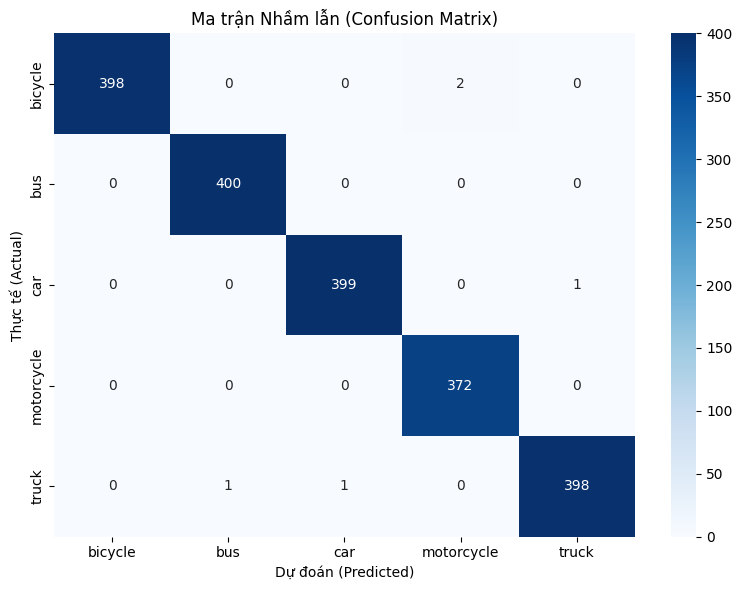

📊 Đã lưu confusion_matrix.png


In [16]:
# =============================================================
# CELL 29: CONFUSION MATRIX
# =============================================================

def ve_confusion_matrix(y_true, y_pred, class_labels: list) -> None:
    """Vẽ ma trận nhầm lẫn (Confusion Matrix)."""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels,
    )
    plt.title("Ma trận Nhầm lẫn (Confusion Matrix)")
    plt.xlabel("Dự đoán (Predicted)")
    plt.ylabel("Thực tế (Actual)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
    plt.show()
    print("📊 Đã lưu confusion_matrix.png")

ve_confusion_matrix(
    eval_results["y_true"],
    eval_results["y_pred"],
    eval_results["class_labels"],
)

In [17]:
# =============================================================
# CELL 30: LƯU KẾT QUẢ EVALUATION
# =============================================================

eval_save = {
    "test_loss": eval_results["test_loss"],
    "test_accuracy": eval_results["test_accuracy"],
    "classification_report": classification_report(
        eval_results["y_true"],
        eval_results["y_pred"],
        target_names=eval_results["class_labels"],
        output_dict=True,
    ),
    "confusion_matrix": confusion_matrix(
        eval_results["y_true"],
        eval_results["y_pred"],
    ).tolist(),
}

eval_file = os.path.join(OUTPUT_DIR, "evaluation_results.json")
with open(eval_file, "w") as f:
    json.dump(eval_save, f, indent=2, ensure_ascii=False)

print(f"💾 Đã lưu kết quả evaluation: {eval_file}")

💾 Đã lưu kết quả evaluation: /kaggle/working/evaluation_results.json


## 🎉 Tóm tắt & Hướng dẫn Download

In [18]:
# =============================================================
# CELL 32: TÓM TẮT & HƯỚNG DẪN DOWNLOAD
# =============================================================

print("=" * 60)
print("🎉 TRAINING HOÀN TẤT!")
print("=" * 60)

print(f"\n📁 Các file output trong {OUTPUT_DIR}/:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, f)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath)
        if size > 1024 * 1024:
            print(f"   • {f} ({size / 1024 / 1024:.1f} MB)")
        elif size > 1024:
            print(f"   • {f} ({size / 1024:.1f} KB)")
        else:
            print(f"   • {f} ({size} B)")

print(f"""
📥 HƯỚNG DẪN DOWNLOAD:
1. Ở tab "Output" bên phải → Download các file:
   • inception_v3_final.h5     → Copy vào models/final/
   • inception_v3_best.h5      → Copy vào models/checkpoints/
   • training_history.json     → Copy vào models/logs/
   • evaluation_results.json   → Copy vào models/logs/
   • training_curves.png       → Dùng cho README/báo cáo
   • confusion_matrix.png      → Dùng cho README/báo cáo

2. Hoặc dùng Kaggle API:
   kaggle kernels output <notebook-slug> -p ./output

🎯 Test Accuracy: {eval_results['test_accuracy']:.4f} ({eval_results['test_accuracy'] * 100:.1f}%)
""")

🎉 TRAINING HOÀN TẤT!

📁 Các file output trong /kaggle/working/:
   • confusion_matrix.png (58.1 KB)
   • evaluation_results.json (1.5 KB)
   • inception_v3_best.h5 (141.5 MB)
   • inception_v3_final.h5 (141.5 MB)
   • training_curves.png (120.4 KB)
   • training_history.json (3.2 KB)
   • training_log.csv (2.6 KB)

📥 HƯỚNG DẪN DOWNLOAD:
1. Ở tab "Output" bên phải → Download các file:
   • inception_v3_final.h5     → Copy vào models/final/
   • inception_v3_best.h5      → Copy vào models/checkpoints/
   • training_history.json     → Copy vào models/logs/
   • evaluation_results.json   → Copy vào models/logs/
   • training_curves.png       → Dùng cho README/báo cáo
   • confusion_matrix.png      → Dùng cho README/báo cáo

2. Hoặc dùng Kaggle API:
   kaggle kernels output <notebook-slug> -p ./output

🎯 Test Accuracy: 0.9975 (99.7%)

